# HEST dataset investigation

In [6]:
import umap
import numpy as np
import os
import plotly.express as px
import datasets
import pandas as pd
from huggingface_hub import login
import matplotlib.pyplot as plt
import seaborn as sns

token = os.getenv("HF_TOKEN")

In [5]:
local_dir='/data/horse/ws/mala059b-rna2wsi/data/hest_data/' # hest will be dowloaded to this folder

meta_df = pd.read_csv("hf://datasets/MahmoodLab/hest/HEST_v1_1_0.csv")

# show the columns of meta_df
meta_df.columns

Index(['dataset_title', 'id', 'image_filename', 'organ', 'disease_state',
       'oncotree_code', 'species', 'patient', 'st_technology',
       'data_publication_date', 'license', 'study_link', 'download_page_link1',
       'inter_spot_dist', 'spot_diameter', 'spots_under_tissue',
       'preservation_method', 'nb_genes', 'treatment_comment',
       'pixel_size_um_embedded', 'pixel_size_um_estimated', 'magnification',
       'fullres_px_width', 'fullres_px_height', 'tissue', 'disease_comment',
       'subseries', 'hest_version_added'],
      dtype='object')

/tmp/ipykernel_958316/3608401695.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='oncotree_code', y='count', data=top_codes, palette='viridis')


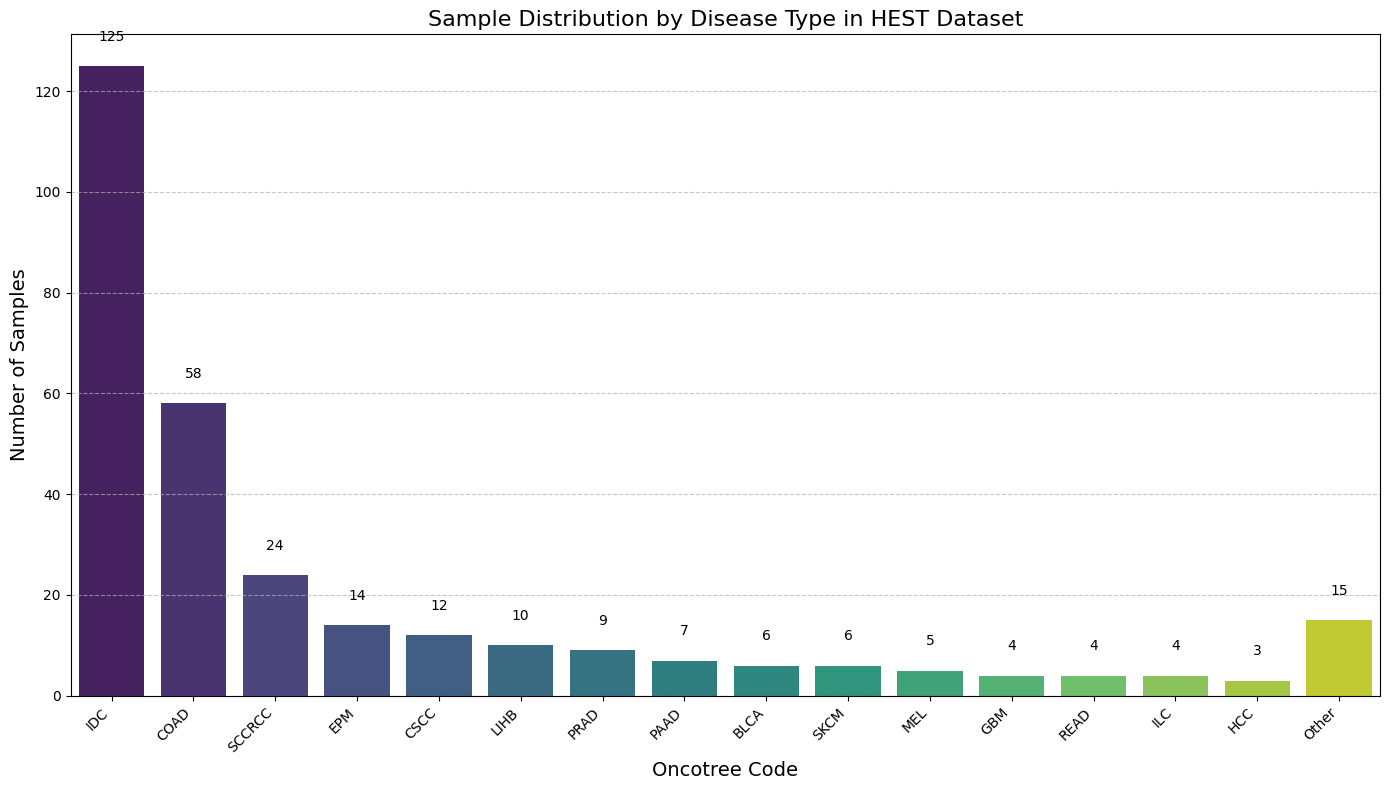

Disease counts in the HEST dataset:


,oncotree_code,count
0,IDC,125
1,COAD,58
2,SCCRCC,24
3,EPM,14
4,CSCC,12
5,LIHB,10
6,PRAD,9
7,PAAD,7
8,BLCA,6
9,SKCM,6


In [7]:
# Count the occurrences of each oncotree_code
oncotree_counts = meta_df['oncotree_code'].value_counts()

# Convert to DataFrame for plotting
counts_df = oncotree_counts.reset_index()
counts_df.columns = ['oncotree_code', 'count']

# Sort by count in descending order
counts_df = counts_df.sort_values(by='count', ascending=False)

# Create a more readable plot by limiting to top diseases
top_n = 15  # Show top 15 diseases
top_codes = counts_df.head(top_n)

# Add "Other" category for remaining diseases
if len(counts_df) > top_n:
    other_count = counts_df.iloc[top_n:]['count'].sum()
    other_row = pd.DataFrame({'oncotree_code': ['Other'], 'count': [other_count]})
    top_codes = pd.concat([top_codes, other_row])

# Create bar plot
plt.figure(figsize=(14, 8))
ax = sns.barplot(x='oncotree_code', y='count', data=top_codes, palette='viridis')

# Add labels and title
plt.title('Sample Distribution by Disease Type in HEST Dataset', fontsize=16)
plt.xlabel('Oncotree Code', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add count labels on top of each bar
for i, v in enumerate(top_codes['count']):
    ax.text(i, v + 5, str(v), ha='center')

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Display the counts as a table as well
print("Disease counts in the HEST dataset:")
display(counts_df)

# Filter for IDC breast cancer data 

Let us just use IDC data because we only have 4 ILC samples.

In [8]:
# search oncotree_code column for IDC 
breast_df = meta_df[meta_df['oncotree_code'].str.contains('IDC', na=False)]
breast_df

,dataset_title,id,image_filename,organ,disease_state,oncotree_code,species,patient,st_technology,data_publication_date,...,treatment_comment,pixel_size_um_embedded,pixel_size_um_estimated,magnification,fullres_px_width,fullres_px_height,tissue,disease_comment,subseries,hest_version_added
153,FFPE Human Breast using the Entire Sample Area,TENX99,TENX99.tif,Breast,Cancer,IDC,Homo sapiens,patient 1,Xenium,1/22/23,...,NaN,1.000000,0.212500,40x,51351,107121,Breast,NaN,Replicate 1,v1_0_0
154,FFPE Human Breast using the Entire Sample Area,TENX98,TENX98.tif,Breast,Cancer,IDC,Homo sapiens,patient 1,Xenium,1/22/23,...,NaN,0.212500,0.212500,40x,51458,111225,Breast,NaN,Replicate 2,v1_0_0
155,FFPE Human Breast with Custom Add-on Panel,TENX97,TENX97.tif,Breast,Cancer,IDC,Homo sapiens,patient 2,Xenium,1/22/23,...,NaN,0.212500,0.212500,40x,48441,53833,Breast,NaN,Tissue sample 1,v1_0_0
157,FFPE Human Breast with Pre-designed Panel,TENX95,TENX95.tif,Breast,Cancer,IDC,Homo sapiens,patient 2,Xenium,1/22/23,...,NaN,1.000000,0.212500,40x,48376,53738,Breast,NaN,Tissue sample 1,v1_0_0
183,Fresh Frozen Visium on CytAssist: Human Breast...,TENX68,TENX68.tif,Breast,Cancer,IDC,Homo sapiens,NaN,Visium,1/6/23,...,NaN,0.264583,0.273835,40x,20690,38232,Breast,NaN,NaN,v1_0_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568,High resolution mapping of the tumor microenvi...,NCBI776,NCBI776.tif,Breast,Cancer,IDC,Homo sapiens,NaN,Visium,9-Oct-23,...,NaN,0.264583,0.547553,20x,19505,21571,Breast,NaN,"Breast Cancer, Visium CytAssist Spatial Gene E...",v1_0_0
621,Single cell profiling of primary and paired me...,NCBI684,NCBI684.tif,Lymph node,Cancer,IDC,Homo sapiens,Patient 3,Visium,30-Apr-22,...,NaN,NaN,0.273475,40x,30014,30174,Lymph node,NaN,PT_3 LNM ST,v1_0_0
622,Single cell profiling of primary and paired me...,NCBI683,NCBI683.tif,Lymph node,Cancer,IDC,Homo sapiens,Patient 6,Visium,30-Apr-22,...,NaN,NaN,0.273423,40x,29616,30094,Lymph node,NaN,PT_6 LNM ST,v1_0_0
623,Single cell profiling of primary and paired me...,NCBI682,NCBI682.tif,Lymph node,Cancer,IDC,Homo sapiens,Patient 7,Visium,30-Apr-22,...,NaN,NaN,0.273876,40x,30014,30254,Lymph node,NaN,PT_7 LNM ST,v1_0_0


In [15]:
# search breast_df for the strings 'TNBC', 'Luminal_A' in all columnsno matter if upper or lower case
breast_df_filtered = breast_df[breast_df.apply(lambda row: row.astype(str).str.contains('TNBC|Luminal_A', case=False).any(), axis=1)]
breast_df_filtered

,dataset_title,id,image_filename,organ,disease_state,oncotree_code,species,patient,st_technology,data_publication_date,...,treatment_comment,pixel_size_um_embedded,pixel_size_um_estimated,magnification,fullres_px_width,fullres_px_height,tissue,disease_comment,subseries,hest_version_added
300,Integrating spatial gene expression and breast...,SPA89,SPA89.tif,Breast,Cancer,IDC,Homo sapiens,BC23268,Spatial Transcriptomics,30-Nov-21,...,NaN,NaN,0.691228,20x,9344,9892,Breast,Luminal_A,BC23268_C1,v1_0_0
301,Integrating spatial gene expression and breast...,SPA88,SPA88.tif,Breast,Cancer,IDC,Homo sapiens,BC23268,Spatial Transcriptomics,30-Nov-21,...,NaN,NaN,0.685273,20x,9291,9908,Breast,Luminal_A,BC23268_C2,v1_0_0
302,Integrating spatial gene expression and breast...,SPA87,SPA87.tif,Breast,Cancer,IDC,Homo sapiens,BC23268,Spatial Transcriptomics,30-Nov-21,...,NaN,NaN,0.683595,20x,9290,9892,Breast,Luminal_A,BC23268_D1,v1_0_0
303,Integrating spatial gene expression and breast...,SPA86,SPA86.tif,Breast,Cancer,IDC,Homo sapiens,BC23269,Spatial Transcriptomics,30-Nov-21,...,NaN,NaN,0.687000,20x,9317,9920,Breast,Luminal_A,BC23269_C1,v1_0_0
304,Integrating spatial gene expression and breast...,SPA85,SPA85.tif,Breast,Cancer,IDC,Homo sapiens,BC23269,Spatial Transcriptomics,30-Nov-21,...,NaN,NaN,0.685516,20x,9293,9947,Breast,Luminal_A,BC23269_C2,v1_0_0
305,Integrating spatial gene expression and breast...,SPA84,SPA84.tif,Breast,Cancer,IDC,Homo sapiens,BC23269,Spatial Transcriptomics,30-Nov-21,...,NaN,NaN,0.685922,20x,9320,9874,Breast,Luminal_A,BC23269_D1,v1_0_0
306,Integrating spatial gene expression and breast...,SPA83,SPA83.tif,Breast,Cancer,IDC,Homo sapiens,BC23272,Spatial Transcriptomics,30-Nov-21,...,NaN,NaN,0.683448,20x,9343,9900,Breast,Luminal_A,BC23272_D2,v1_0_0
307,Integrating spatial gene expression and breast...,SPA82,SPA82.tif,Breast,Cancer,IDC,Homo sapiens,BC23272,Spatial Transcriptomics,30-Nov-21,...,NaN,NaN,0.689919,20x,9278,9915,Breast,Luminal_A,BC23272_E1,v1_0_0
308,Integrating spatial gene expression and breast...,SPA81,SPA81.tif,Breast,Cancer,IDC,Homo sapiens,BC23272,Spatial Transcriptomics,30-Nov-21,...,NaN,NaN,0.687175,20x,9331,9914,Breast,Luminal_A,BC23272_E2,v1_0_0
309,Integrating spatial gene expression and breast...,SPA80,SPA80.tif,Breast,Cancer,IDC,Homo sapiens,BC24223,Spatial Transcriptomics,30-Nov-21,...,NaN,NaN,0.684893,20x,9351,9896,Breast,Luminal_A,BC24223_D2,v1_0_0


There are entries for Luminal A subtype and for Triple negative breast cancer (TNBC). Basal-like subtype cannot be treated equal to TNBC, but approx 70-90% of TNBC should be basal-like.

In [17]:
# create a list called ids_to_query that contains id column of breast_df_filtered
ids_to_query = breast_df_filtered['id'].tolist()

In [18]:
list_patterns = [f"*{id}[_.]**" for id in ids_to_query]
dataset = datasets.load_dataset(
    'MahmoodLab/hest', 
    cache_dir=local_dir,
    patterns=list_patterns
)

README.md:   0%|          | 0.00/6.96k [00:00<?, ?B/s]

hest.py:   0%|          | 0.00/2.17k [00:00<?, ?B/s]

RuntimeError: Dataset scripts are no longer supported, but found hest.py

In [ ]:
	from hest import iter_hest

for st in iter_hest('../hest_data', id_list=['SPA89']):
    print(st)